# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?

General linear models have the advantage of allowing different distributions instead of just assuming a linear relationship between input and output. They can model non Gaussian data, such as probabilities.

2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.

They're effective loss functions because they are statistically consistent with the probabilistic model, as they penalize confident wrong predictions and minimize cross entropy loss.

3. True or false, and explain: Logistic regression is a linear model.

True, logistic regression is a linear model (with the parameters as w^Tx), but the output is not linear

4. True or false, and explain: Logistic regression cannot be used for classification.

False, logistic regression is actually used for classification as it has probabilities as outputs, which then get converted to class labels

5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?

The coefficient in logistic regression is the change in log odds, so a one unit increase wouldn't change the probability, but the log odds linearly (the effect on probability instead depends on the current value)

6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.

False, logistic regression is linear, only the output transformation is impacted by nonlinearity 

7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

False, you should use logistic regression when there is a categorical response, and OLS should be used when there is a continuous response. Logistic regression wouldn't be the best for gaussian noise assumptions for example, so it depends on the needs

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# filter to relevant columns only
columns = ['Debtor', 'Tuition fees up to date', 'Scholarship holder',
        'Age at enrollment', 'Curricular units 1st sem (approved)', 'Target']

df = pd.read_csv('data\data.csv', sep = ';', usecols = columns)

print(df.isna().sum()) # no NA values so no need to drop anything

df['Dropout'] = (df['Target'] == 'Dropout').astype(int) # binary target for Dropout (1 = dropout, 0 = grad/enrolled)

df.head()

Debtor                                 0
Tuition fees up to date                0
Scholarship holder                     0
Age at enrollment                      0
Curricular units 1st sem (approved)    0
Target                                 0
dtype: int64


<>:10: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:10: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\emili\AppData\Local\Temp\ipykernel_29736\3182904820.py:10: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df = pd.read_csv('data\data.csv', sep = ';', usecols = columns)


,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Target,Dropout
0,0,1,0,20,0,Dropout,1
1,0,0,0,19,6,Graduate,0
2,0,0,0,19,0,Dropout,1
3,0,1,0,20,6,Graduate,0
4,0,1,0,45,5,Graduate,0



2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

In [14]:
from sklearn.linear_model import LogisticRegression

features = ['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment']
X = df[features]
y = df['Dropout']

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

results = pd.DataFrame({
    'Coefficient': model.coef_[0],
    'Odds Ratio': np.exp(model.coef_[0])
}, index=features)

print(results.round(4))
print(f"\nIntercept: {model.intercept_[0]:.4f}")
print(f"Accuracy: {model.score(X, y):.4f}")

                         Coefficient  Odds Ratio
Debtor                        0.5306      1.7000
Tuition fees up to date      -2.5565      0.0776
Scholarship holder           -1.2274      0.2930
Age at enrollment             0.0499      1.0512

Intercept: 0.4857
Accuracy: 0.7620


`Debtor` and `Age at enrollment` are variables that predict higher dropout probability, while `Tuition up to date` and `Scholarship holder` are variables that predict lower dropout probability.

`Debtor (coef = +0.53, OR = 1.70):` Students with outstanding debt have about 1.7× the odds of dropping out compared to non-debtors.

`Age at enrollment (coef = +0.05, OR = 1.05):` Each additional year of age is associated with a 5% increase in dropout odds. A 30-year-old enrollee has ~1.63× the odds of a 20-year-old.

`Tuition fees up to date (coef = -2.56, OR = 0.08):` By far the strongest predictor. Students current on tuition have only about 8% of the dropout odds of those who aren't (a reduction of over 92%.)

`Scholarship holder (coef = -1.23, OR = 0.29):` Scholarship recipients have roughly 29% of the dropout odds of non-recipients, about a 71% reduction.

`Does being up to date on tuition reduce dropout risk?`
Yes. With an odds ratio of ~0.08 it is the single most influential variable in the model. One caveat is that causality runs both ways, as students who have already decided to leave may simply stop paying, meaning the variable may partly reflect dropout status rather than fully drive it.



3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

Tuition fees up to date
0    0.860675
1    0.248090
Name: pred_prob, dtype: float64


(0.0, 1.0)

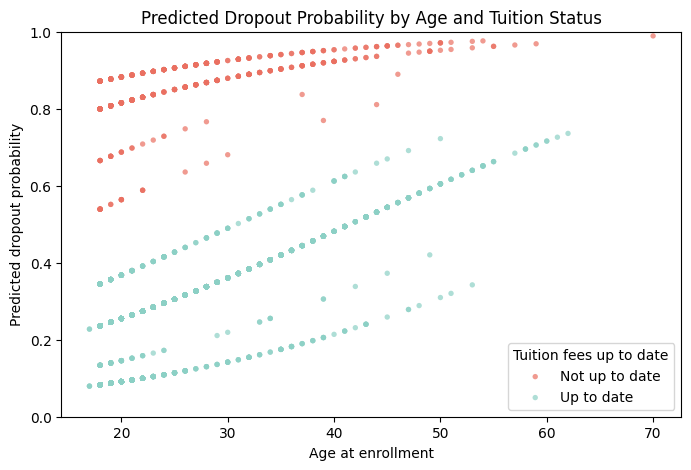

In [33]:
features = ['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment']
X = df[features]
y = df['Dropout']

model = LogisticRegression(max_iter=1000)  # C=np.inf disables regularization
model.fit(X, y)
df['pred_prob'] = model.predict_proba(X)[:, 1]

# average difference by tuition status
print(df.groupby('Tuition fees up to date')['pred_prob'].mean())

# scatterplot
fig, ax = plt.subplots(figsize=(8, 5))

for status, label, color in [(0, 'Not up to date', '#EA7061'), (1, 'Up to date', '#8CD0C5')]:
    sub = df[df['Tuition fees up to date'] == status]
    ax.scatter(sub['Age at enrollment'], sub['pred_prob'],
               color=color, label=label, alpha=0.7, s=15, edgecolors='none')

ax.set_xlabel('Age at enrollment')
ax.set_ylabel('Predicted dropout probability')
ax.set_title('Predicted Dropout Probability by Age and Tuition Status')
ax.legend(title='Tuition fees up to date')
ax.set_ylim(0, 1)

`For what ages does tuition status matter most?` 
The gap between the two groups is fairly stable across ages, with it being roughly 0.60–0.62 probability points for younger students (18–22) and narrows slightly at older ages as both curves rise together. So tuition status is influential at every age, but more so for younger students.

`On average, by how much does being up to date on tuition change the predicted probability of dropout?`
On average, being up to date on tuition reduces the predicted dropout probability by about 0.61 (from ~0.86 down to ~0.25). This is a very large effect, consistent with what the odds ratio told us in Q2.


4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

In [34]:
from sklearn.metrics import confusion_matrix, accuracy_score

y_pred = model.predict(X)

cm = confusion_matrix(y, y_pred)
print("Confusion Matrix:")
print(cm)
print(f"\nAccuracy: {accuracy_score(y, y_pred):.4f}")

Confusion Matrix:
[[2841  162]
 [ 891  530]]

Accuracy: 0.7620


The model correctly classifies 76.2% of students.

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

Logistic accuracy: 0.7620
Linear accuracy:      0.7633


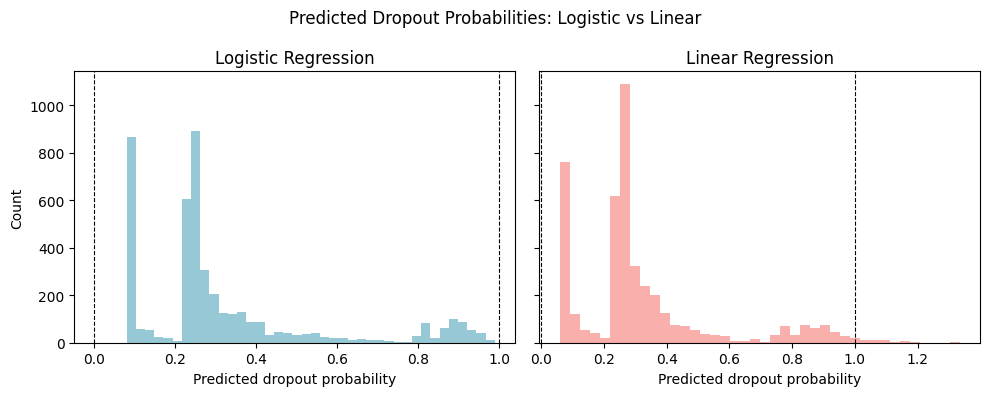

In [37]:
from sklearn.linear_model import LinearRegression

# logistic
logic = LogisticRegression(max_iter=1000)
logic.fit(X, y)
prob_logit = logic.predict_proba(X)[:, 1]

# linear
lin = LinearRegression()
lin.fit(X, y)
prob_lpm = lin.predict(X)

print(f"Logistic accuracy: {accuracy_score(y, (prob_logit >= 0.5).astype(int)):.4f}")
print(f"Linear accuracy:      {accuracy_score(y, (prob_lpm   >= 0.5).astype(int)):.4f}")

# histograms
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axes[0].hist(prob_logit, bins=40, color='#96C8D5', edgecolor='none')
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted dropout probability')
axes[0].set_ylabel('Count')
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].axvline(1, color='black', linewidth=0.8, linestyle='--')

axes[1].hist(prob_lpm, bins=40, color='#F9AFAC', edgecolor='none')
axes[1].set_title('Linear Regression')
axes[1].set_xlabel('Predicted dropout probability')
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].axvline(1, color='black', linewidth=0.8, linestyle='--')

plt.suptitle('Predicted Dropout Probabilities: Logistic vs Linear')
plt.tight_layout()



The dashed lines mark 0 and 1, the valid probability range. Logistic regression respects these bounds by construction as all predictions fall neatly between 0 and 1. The linear model  does not, with a handful of predictions exceeding 1.0 and extending to ~1.2.

In terms of accuracy at the 0.5 threshold the two models are essentially tied at 76.2% (logistic) vs 76.3% (linear). For simple classification they perform the same. The linear model's main weakness is the out-of-bounds predictions. For this dataset the problem is minor, but logistic regression is still the more principled choice when the goal is predicting probabilities rather than just class labels.

6. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

Based on the logistic regression, the highest-risk profile is a student who is behind on tuition, has outstanding debt, is older at enrollment, and holds no scholarship. These factors compound: a debtor who is also behind on tuition faces dramatically higher predicted dropout odds than any single risk factor alone would suggest. Age matters too, but it's the financial variables that are most dominant.

Given that financial variables seem to be the most influential, potential interventions could be emergency hardship funds, short-term tuition deferral, and expanded scholarship eligibility for students just above income cutoffs.

7. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

In [38]:
features = ['Debtor', 'Tuition fees up to date', 'Curricular units 1st sem (approved)']
X = df[features]
y = df['Target']

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

# hard classification
y_pred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred):.4f}")
print("\nConfusion Matrix:")
print(pd.DataFrame(
    confusion_matrix(y, y_pred, labels=model.classes_),
    index=model.classes_, columns=model.classes_
))

# Predicted probabilities
proba_df = pd.DataFrame(model.predict_proba(X), columns=model.classes_)
print("\nMean predicted probability per class:")
print(proba_df.mean().round(4))
print("\nMax predicted probability per class:")
print(proba_df.max().round(4))

Accuracy: 0.7046

Confusion Matrix:
          Dropout  Enrolled  Graduate
Dropout      1054         0       367
Enrolled      280         0       514
Graduate      146         0      2063

Mean predicted probability per class:
Dropout     0.3212
Enrolled    0.1795
Graduate    0.4993
dtype: float64

Max predicted probability per class:
Dropout     0.9602
Enrolled    0.3278
Graduate    0.9997
dtype: float64


Accuracy is 70.5%, lower than the binary model in Q2/Q4 since three-class classification is a harder problem.

`Does your hard classification predict every class?`
No. The confusion matrix reveals that the model never predicts Enrolled (entire column is 0..). All 794 enrolled students get misclassified as either Dropout or Graduate. The hard classifier essentially collapses into a binary problem, because Enrolled is the smallest class and the model never finds it the most probable outcome for any single student.

`Do your predicted probabilities predict every class?`
Yes. The mean predicted probability for Enrolled is 0.18 and the maximum is 0.33. However, for every student, either Dropout or Graduate always has a higher predicted probability than Enrolled, so it never wins the hard classification, which is expected due to its smaller class size.

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics 
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class? 

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio? 